## Proteomics — `4_Harmonized_MS_CCLE_Gygi_subsetted.csv`

375 cell lines × 12,558 proteins measured by mass spectrometry — tells us what proteins are actually present, not just what genes are switched on. Values are harmonized, centred relative abundances (can be negative): per-protein mean is ~0 but variance is NOT unit (per-protein std median ~0.80), so this is standardised, not strict z-score. Missing values mean the protein was not detected; use a detection-floor imputation, not mean. Row index (`Unnamed: 0`) is DepMap `ModelID` (`ACH-...`).

In [1]:
import __init__ as ini
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100


In [2]:
%%time
df = pd.read_csv(ini.df4)

CPU times: total: 734 ms
Wall time: 765 ms


In [3]:
df

,Unnamed: 0,A0AV96 (RBM47),A0AVF1 (IFT56),A0AVG3 (TSNARE1),A0AVI4 (TMEM129),A0AVK6 (E2F8),A0AVT1 (UBA6),A0JLT2 (MED19),A0JNW5 (BLTP3B),A0MZ66 (SHTN1),...,Q9Y6N7-2 (ROBO1),Q9Y4E1-4 (WASHC2C),Q9Y6Q5-2 (AP1M2),Q9Y6K9-2 (IKBKG),Q9Y3Y2-3 (CHTOP),Q9Y4P1-2 (ATG4B),Q9Y6I3-1 (EPN1),Q9Y5V3-2 (MAGED1),Q9Y575-3 (ASB3),Q9Y2L9-2 (LRCH1)
0,ACH-000849,0.358567,-0.172066,NaN,NaN,NaN,-0.496842,0.267691,0.045754,0.065342,...,0.255903,-0.081142,1.680544,0.001122,0.684397,0.397332,0.209930,-0.197547,NaN,-1.100381
1,ACH-000441,-1.112410,0.339446,NaN,NaN,NaN,-0.395633,-0.262715,-0.414909,-0.396370,...,0.199431,-0.300508,-0.414740,0.178375,-0.387377,-0.008456,-0.482339,0.148685,NaN,0.484499
2,ACH-000248,0.855575,-0.181171,NaN,NaN,NaN,-0.284720,-0.436849,0.555351,1.550787,...,-0.849680,0.096941,1.120568,-0.512328,0.102240,-0.204140,0.039421,-0.761104,NaN,-1.191209
3,ACH-000684,0.061377,-0.341233,NaN,NaN,NaN,1.481536,-0.006424,0.185271,-0.125160,...,-0.230147,0.148388,-0.162396,0.279161,-0.057371,-0.331465,-0.014308,0.617058,NaN,0.409230
4,ACH-000856,0.284258,-0.059558,NaN,NaN,NaN,-0.520511,0.680164,-0.281309,-0.691303,...,-0.024407,0.698199,-0.518353,-0.292139,0.498029,0.283140,-0.123974,-0.560028,NaN,-0.120029
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370,ACH-000846,0.348655,-1.032205,NaN,NaN,NaN,-0.611541,0.473297,-0.523671,1.909424,...,-0.943454,0.274945,0.221292,0.467104,-0.862766,-1.432287,-0.037488,-0.531392,NaN,0.235568
371,ACH-000265,-1.442707,-0.684201,NaN,NaN,NaN,-0.729435,0.763294,0.043234,0.659305,...,1.375092,0.813708,-0.336331,0.962541,0.030003,-0.364443,0.060838,1.521803,NaN,-0.144655
372,ACH-000006,0.436273,-0.770205,NaN,NaN,NaN,0.965691,-0.135442,0.204895,-0.680679,...,-1.813197,-0.879452,-0.671954,0.506344,0.291667,1.241690,-0.264163,-0.065897,NaN,-0.145264
373,ACH-000696,-1.585523,0.289067,NaN,NaN,NaN,0.373398,-0.329539,-0.114584,-0.249955,...,1.406823,0.685588,-0.813471,0.767487,-0.489870,-0.457437,0.373700,0.348390,NaN,0.671977


In [4]:
df.shape

(375, 12559)

In [5]:
print(df.head())

   Unnamed: 0  A0AV96 (RBM47)  A0AVF1 (IFT56)  A0AVG3 (TSNARE1)  \
0  ACH-000849        0.358567       -0.172066               NaN   
1  ACH-000441       -1.112410        0.339446               NaN   
2  ACH-000248        0.855575       -0.181171               NaN   
3  ACH-000684        0.061377       -0.341233               NaN   
4  ACH-000856        0.284258       -0.059558               NaN   

   A0AVI4 (TMEM129)  A0AVK6 (E2F8)  A0AVT1 (UBA6)  A0JLT2 (MED19)  \
0               NaN            NaN      -0.496842        0.267691   
1               NaN            NaN      -0.395633       -0.262715   
2               NaN            NaN      -0.284720       -0.436849   
3               NaN            NaN       1.481536       -0.006424   
4               NaN            NaN      -0.520511        0.680164   

   A0JNW5 (BLTP3B)  A0MZ66 (SHTN1)  ...  Q9Y6N7-2 (ROBO1)  Q9Y4E1-4 (WASHC2C)  \
0         0.045754        0.065342  ...          0.255903           -0.081142   
1        -0.414909  

### Rename index and identify protein columns

In [6]:
df = df.rename(columns={"Unnamed: 0": "ModelID"}).set_index("ModelID")
prot_cols = df.columns.tolist()
print(f"Cell lines (rows): {len(df)}")
print(f"Proteins (cols)  : {len(prot_cols)}")


Cell lines (rows): 375
Proteins (cols)  : 12558


### Missingness — the bimodal pattern
Proteomics NaN means 'not detected', not random missing data. The histogram below should show a bimodal pattern: proteins are either detected in almost all lines or in very few.

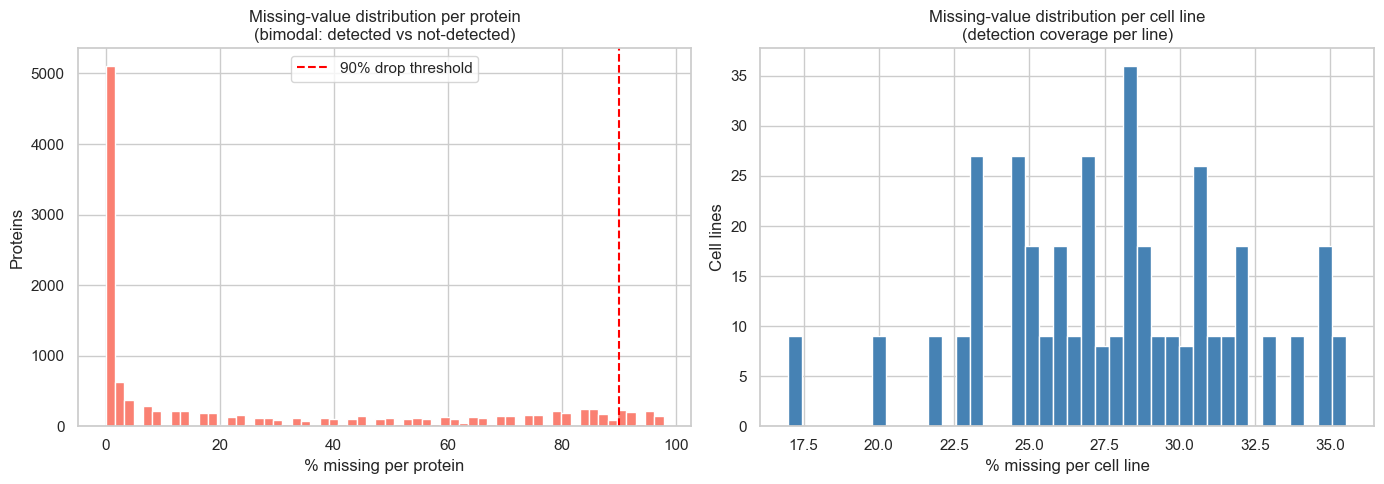

Proteins >90% missing (drop): 834
Proteins <50% missing (keep): 9014


In [7]:
pct_missing_per_protein = df.isnull().mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(pct_missing_per_protein, bins=60, color="salmon", edgecolor="white")
axes[0].set_xlabel("% missing per protein"); axes[0].set_ylabel("Proteins")
axes[0].set_title("Missing-value distribution per protein\n(bimodal: detected vs not-detected)")
axes[0].axvline(90, color="red", linestyle="--", label="90% drop threshold")
axes[0].legend()

pct_missing_per_line = df.isnull().mean(axis=1) * 100
axes[1].hist(pct_missing_per_line, bins=40, color="steelblue", edgecolor="white")
axes[1].set_xlabel("% missing per cell line"); axes[1].set_ylabel("Cell lines")
axes[1].set_title("Missing-value distribution per cell line\n(detection coverage per line)")

plt.tight_layout(); plt.show()
print(f"Proteins >90% missing (drop): {(pct_missing_per_protein > 90).sum()}")
print(f"Proteins <50% missing (keep): {(pct_missing_per_protein < 50).sum()}")


### Z-score distribution
Values are centred near 0 (per-protein mean median ~ -0.02) but are NOT unit-variance (per-protein std median ~0.80; full range about -23 to +13) - harmonized relative abundance, not strict z-score. The violin confirms the centring.

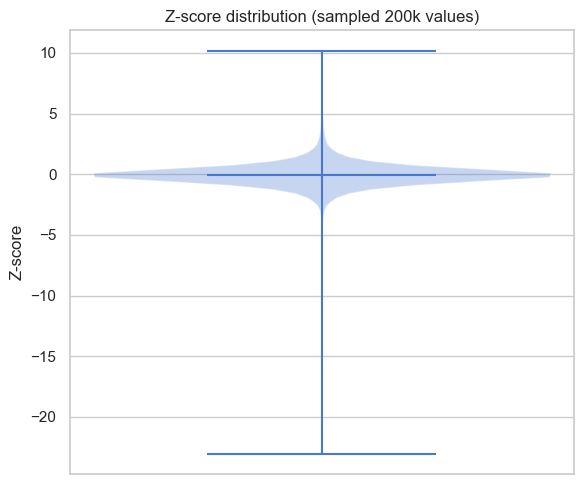

Mean: -0.028  Std: 0.964


In [8]:
# sample for speed
sample_vals = df.values.flatten()
sample_vals = sample_vals[~np.isnan(sample_vals)]
np.random.seed(42)
if len(sample_vals) > 200_000:
    sample_vals = np.random.choice(sample_vals, 200_000, replace=False)

fig, ax = plt.subplots(figsize=(6, 5))
ax.violinplot(sample_vals, showmedians=True)
ax.set_title("Z-score distribution (sampled 200k values)")
ax.set_ylabel("Z-score"); ax.set_xticks([])
plt.tight_layout(); plt.show()
print(f"Mean: {sample_vals.mean():.3f}  Std: {sample_vals.std():.3f}")


### PCA of cell lines by proteome
We use only proteins detected in ≥50% of cell lines to avoid imputation bias.

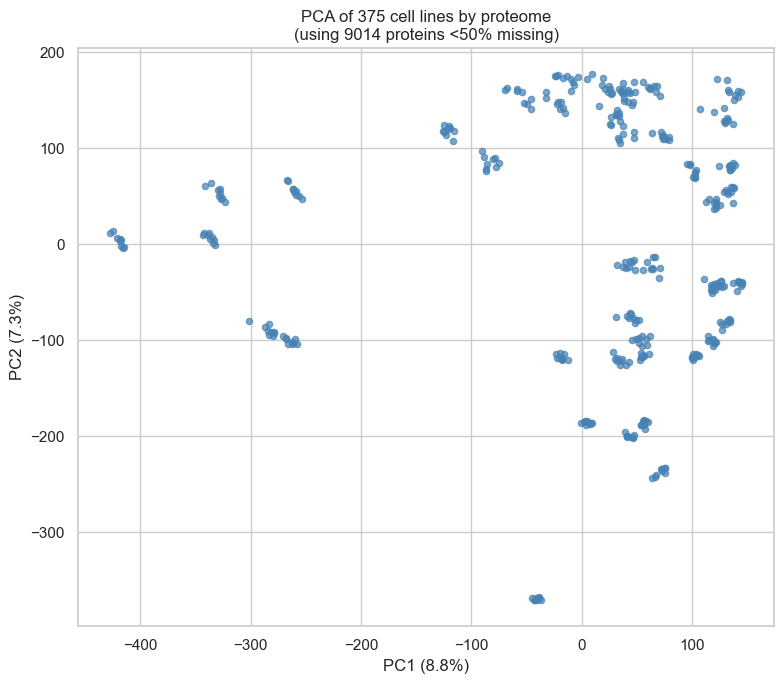

In [9]:
keep_prot = pct_missing_per_protein[pct_missing_per_protein < 50].index
X_prot = df[keep_prot].fillna(df[keep_prot].min().min())  # impute with floor

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_prot)
var_exp = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(coords[:, 0], coords[:, 1], alpha=0.7, s=20, color="steelblue")
ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}%)")
ax.set_title(f"PCA of {len(df)} cell lines by proteome\n(using {len(keep_prot)} proteins <50% missing)")
plt.tight_layout(); plt.show()


### Most variable proteins
High-variance proteins best differentiate cell lines — these are the most useful features.

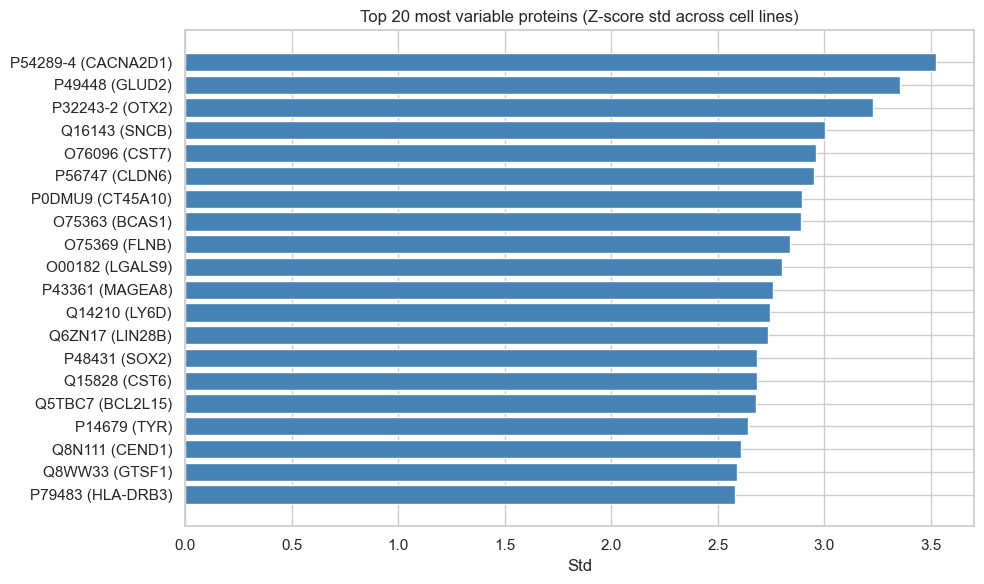

In [10]:
prot_std = df[keep_prot].std().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top20 = prot_std.head(20)
ax.barh(top20.index[::-1], top20.values[::-1], color="steelblue")
ax.set_title("Top 20 most variable proteins (Z-score std across cell lines)")
ax.set_xlabel("Std")
plt.tight_layout(); plt.show()


### Key findings

In [11]:
print("=== Proteomics (CCLE/Gygi) ===")
print(f"Cell lines                    : {len(df)}")
print(f"Total proteins                : {len(prot_cols)}")
print(f"Proteins >90% missing (drop)  : {(pct_missing_per_protein>90).sum()}")
print(f"Proteins <50% missing (use)   : {len(keep_prot)}")
print(f"PCA PC1+PC2 variance          : {sum(pca.explained_variance_ratio_)*100:.1f}%")


=== Proteomics (CCLE/Gygi) ===
Cell lines                    : 375
Total proteins                : 12558
Proteins >90% missing (drop)  : 834
Proteins <50% missing (use)   : 9014
PCA PC1+PC2 variance          : 16.1%


## Join Analysis — how this table connects to the others

df4's row index (originally `Unnamed: 0`) holds DepMap **ModelIDs** (`ACH-...`),
the same canonical key used by df9. The join is a single hop and should be clean.

| From | Key column | To | Key column | Cardinality | Notes |
|---|---|---|---|---|---|
| df4 | index (ACH-...) | df9 | `DepMap_ID` | 1:1 | direct join |
| df4 via df9 | ModelID | df2 via df8 | ModelID | 1:1 | proteomics + RNA |
| df4 via df9 | ModelID | df5 | `ModelID` | 1:1 | proteomics + fusions |

**Biological note:** Proteomics covers only ~375 of DepMap's ~1,840 lines — the
smallest footprint of any omics layer. Combined models using proteomics will be
trained on this narrow, potentially biased subset.


In [12]:
# ── A/B: Join coverage df4 → df9 ────────────────────────────────────────────
df9_ids = pd.read_csv(ini.df9, usecols=["DepMap_ID", "lineage", "primary_disease"])

prot_models = set(df.index)                        # df4 index = ModelID after EDA rename
df9_models  = set(df9_ids["DepMap_ID"].dropna())
matched     = prot_models & df9_models
lost_prot   = prot_models - df9_models              # in df4, not in df9
df9_only    = df9_models - prot_models              # in df9, no proteomics

print("=== df4 join: index (ACH-) → df9 DepMap_ID ===")
print(f"df4 cell lines (ModelID index) : {len(prot_models)}")
print(f"Matched in df9                 : {len(matched)} ({len(matched)/len(prot_models)*100:.1f}%)")
print(f"Lost (df4 not in df9)          : {len(lost_prot)}")
print(f"df9 lines with no proteomics   : {len(df9_only)} ({len(df9_only)/len(df9_models)*100:.1f}%)")
print()
# Cross-dataset
df2_models = set(pd.read_csv(ini.df8, usecols=["ModelID","Datatype"])
                   .query("Datatype=='rna'")["ModelID"])
print(f"df4 models also in df2 (RNA)   : {len(matched & df2_models)}")
print(f"df4 models also in df5 (fusions): {len(matched & set(pd.read_csv(ini.df5, usecols=['ModelID'])['ModelID'].dropna()))}")


=== df4 join: index (ACH-) → df9 DepMap_ID ===
df4 cell lines (ModelID index) : 375
Matched in df9                 : 375 (100.0%)
Lost (df4 not in df9)          : 0
df9 lines with no proteomics   : 1465 (79.6%)

df4 models also in df2 (RNA)   : 369


df4 models also in df5 (fusions): 370


In [13]:
# ── C: Format check on df4 index (ModelID) ──────────────────────────────────
def fmt_check(series, name, prefix=None):
    s = series.dropna().astype(str)
    print(f"Format check — {name} (n={len(s)} non-null, {series.isna().sum()} NaN):")
    print(f"  Leading whitespace  : {s.str.startswith(' ').any()}")
    print(f"  Trailing whitespace : {s.str.endswith(' ').any()}")
    if prefix:
        ok = s.str.startswith(prefix).all()
        print(f"  All start '{prefix}'  : {ok}")
        if not ok:
            print(f"  Non-prefix examples : {s[~s.str.startswith(prefix)].head(3).tolist()}")
    lens = s.str.len()
    print(f"  Length range        : {lens.min()} – {lens.max()}")
    dups = series.duplicated().sum()
    print(f"  Duplicates          : {dups}")


fmt_check(pd.Series(list(prot_models)), "df4 index (ModelID)", prefix="ACH-")
print()
# Also check df9 DepMap_ID for same format
fmt_check(df9_ids["DepMap_ID"], "df9 DepMap_ID", prefix="ACH-")
print()
# Cross-format consistency: do both use same zero-padding?
sample_prot = sorted(prot_models)[:3]
sample_df9  = sorted(df9_models)[:3]
print(f"df4 sample IDs: {sample_prot}")
print(f"df9 sample IDs: {sample_df9}")


Format check — df4 index (ModelID) (n=375 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'ACH-'  : True
  Length range        : 10 – 10
  Duplicates          : 0

Format check — df9 DepMap_ID (n=1840 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'ACH-'  : True
  Length range        : 10 – 10
  Duplicates          : 0

df4 sample IDs: ['ACH-000001', 'ACH-000004', 'ACH-000005']
df9 sample IDs: ['ACH-000001', 'ACH-000002', 'ACH-000003']


### Biological implications

With only 375 cell lines, proteomics is the most coverage-limited layer.
The df9 lines WITHOUT proteomics data (~79%) represent a training-data gap —
any model using protein expression will be trained on a subset that may not
represent all cancer lineages proportionally.


In [14]:
# Biological: lineage distribution of covered vs uncovered lines
covered_df9  = df9_ids[df9_ids["DepMap_ID"].isin(matched)]
missing_df9  = df9_ids[df9_ids["DepMap_ID"].isin(df9_only)]

print("Lineages WITH proteomics data (top 10):")
print(covered_df9["lineage"].value_counts().head(10).to_string())
print()
print("Lineages WITHOUT proteomics (top 10 missing):")
print(missing_df9["lineage"].value_counts().head(10).to_string())
print()
# Coverage fraction per lineage
total_per_lineage = df9_ids["lineage"].value_counts()
prot_per_lineage  = covered_df9["lineage"].value_counts()
coverage_pct = (prot_per_lineage / total_per_lineage * 100).dropna().sort_values()
print("Proteomics coverage % per lineage (lowest first):")
print(coverage_pct.head(10).round(1).to_string())


Lineages WITH proteomics data (top 10):
lineage
lung          79
skin          33
breast        30
colorectal    30
blood         23
pancreas      20
ovary         17
gastric       14
esophagus     14
uterus        14

Lineages WITHOUT proteomics (top 10 missing):
lineage
lung                      195
blood                     118
lymphocyte                100
central_nervous_system     95
skin                       87
bone                       72
upper_aerodigestive        69
soft_tissue                65
ovary                      57
breast                     56

Proteomics coverage % per lineage (lowest first):
lineage
peripheral_nervous_system     2.0
unknown                       2.1
bile_duct                     2.3
soft_tissue                   8.5
bone                          8.9
lymphocyte                    9.1
thyroid                       9.5
upper_aerodigestive          12.7
central_nervous_system       12.8
blood                        16.3


## Join Analysis — how this table connects to the others

df4's row index (originally `Unnamed: 0`) holds DepMap **ModelIDs** (`ACH-...`),
the same canonical key used by df9. The join is a single hop and should be clean.

| From | Key column | To | Key column | Cardinality | Notes |
|---|---|---|---|---|---|
| df4 | index (ACH-...) | df9 | `DepMap_ID` | 1:1 | direct join |
| df4 via df9 | ModelID | df2 via df8 | ModelID | 1:1 | proteomics + RNA |
| df4 via df9 | ModelID | df5 | `ModelID` | 1:1 | proteomics + fusions |

**Biological note:** Proteomics covers only ~375 of DepMap's ~1,840 lines — the
smallest footprint of any omics layer. Combined models using proteomics will be
trained on this narrow, potentially biased subset.


In [15]:
# ── A/B: Join coverage df4 → df9 ────────────────────────────────────────────
df9_ids = pd.read_csv(ini.df9, usecols=["DepMap_ID", "lineage", "primary_disease"])

prot_models = set(df.index)                        # df4 index = ModelID after EDA rename
df9_models  = set(df9_ids["DepMap_ID"].dropna())
matched     = prot_models & df9_models
lost_prot   = prot_models - df9_models              # in df4, not in df9
df9_only    = df9_models - prot_models              # in df9, no proteomics

print("=== df4 join: index (ACH-) → df9 DepMap_ID ===")
print(f"df4 cell lines (ModelID index) : {len(prot_models)}")
print(f"Matched in df9                 : {len(matched)} ({len(matched)/len(prot_models)*100:.1f}%)")
print(f"Lost (df4 not in df9)          : {len(lost_prot)}")
print(f"df9 lines with no proteomics   : {len(df9_only)} ({len(df9_only)/len(df9_models)*100:.1f}%)")
print()
# Cross-dataset
df2_models = set(pd.read_csv(ini.df8, usecols=["ModelID","Datatype"])
                   .query("Datatype=='rna'")["ModelID"])
print(f"df4 models also in df2 (RNA)   : {len(matched & df2_models)}")
print(f"df4 models also in df5 (fusions): {len(matched & set(pd.read_csv(ini.df5, usecols=['ModelID'])['ModelID'].dropna()))}")


=== df4 join: index (ACH-) → df9 DepMap_ID ===
df4 cell lines (ModelID index) : 375
Matched in df9                 : 375 (100.0%)
Lost (df4 not in df9)          : 0
df9 lines with no proteomics   : 1465 (79.6%)

df4 models also in df2 (RNA)   : 369


df4 models also in df5 (fusions): 370


In [16]:
# ── C: Format check on df4 index (ModelID) ──────────────────────────────────
def fmt_check(series, name, prefix=None):
    s = series.dropna().astype(str)
    print(f"Format check — {name} (n={len(s)} non-null, {series.isna().sum()} NaN):")
    print(f"  Leading whitespace  : {s.str.startswith(' ').any()}")
    print(f"  Trailing whitespace : {s.str.endswith(' ').any()}")
    if prefix:
        ok = s.str.startswith(prefix).all()
        print(f"  All start '{prefix}'  : {ok}")
        if not ok:
            print(f"  Non-prefix examples : {s[~s.str.startswith(prefix)].head(3).tolist()}")
    lens = s.str.len()
    print(f"  Length range        : {lens.min()} – {lens.max()}")
    dups = series.duplicated().sum()
    print(f"  Duplicates          : {dups}")


fmt_check(pd.Series(list(prot_models)), "df4 index (ModelID)", prefix="ACH-")
print()
# Also check df9 DepMap_ID for same format
fmt_check(df9_ids["DepMap_ID"], "df9 DepMap_ID", prefix="ACH-")
print()
# Cross-format consistency: do both use same zero-padding?
sample_prot = sorted(prot_models)[:3]
sample_df9  = sorted(df9_models)[:3]
print(f"df4 sample IDs: {sample_prot}")
print(f"df9 sample IDs: {sample_df9}")


Format check — df4 index (ModelID) (n=375 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'ACH-'  : True
  Length range        : 10 – 10
  Duplicates          : 0

Format check — df9 DepMap_ID (n=1840 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'ACH-'  : True
  Length range        : 10 – 10
  Duplicates          : 0

df4 sample IDs: ['ACH-000001', 'ACH-000004', 'ACH-000005']
df9 sample IDs: ['ACH-000001', 'ACH-000002', 'ACH-000003']


### Biological implications

With only 375 cell lines, proteomics is the most coverage-limited layer.
The df9 lines WITHOUT proteomics data (~79%) represent a training-data gap —
any model using protein expression will be trained on a subset that may not
represent all cancer lineages proportionally.


In [17]:
# Biological: lineage distribution of covered vs uncovered lines
covered_df9  = df9_ids[df9_ids["DepMap_ID"].isin(matched)]
missing_df9  = df9_ids[df9_ids["DepMap_ID"].isin(df9_only)]

print("Lineages WITH proteomics data (top 10):")
print(covered_df9["lineage"].value_counts().head(10).to_string())
print()
print("Lineages WITHOUT proteomics (top 10 missing):")
print(missing_df9["lineage"].value_counts().head(10).to_string())
print()
# Coverage fraction per lineage
total_per_lineage = df9_ids["lineage"].value_counts()
prot_per_lineage  = covered_df9["lineage"].value_counts()
coverage_pct = (prot_per_lineage / total_per_lineage * 100).dropna().sort_values()
print("Proteomics coverage % per lineage (lowest first):")
print(coverage_pct.head(10).round(1).to_string())


Lineages WITH proteomics data (top 10):
lineage
lung          79
skin          33
breast        30
colorectal    30
blood         23
pancreas      20
ovary         17
gastric       14
esophagus     14
uterus        14

Lineages WITHOUT proteomics (top 10 missing):
lineage
lung                      195
blood                     118
lymphocyte                100
central_nervous_system     95
skin                       87
bone                       72
upper_aerodigestive        69
soft_tissue                65
ovary                      57
breast                     56

Proteomics coverage % per lineage (lowest first):
lineage
peripheral_nervous_system     2.0
unknown                       2.1
bile_duct                     2.3
soft_tissue                   8.5
bone                          8.9
lymphocyte                    9.1
thyroid                       9.5
upper_aerodigestive          12.7
central_nervous_system       12.8
blood                        16.3


## Deeper dive: does RNA predict protein? (df4 vs df2)

Drug targets are proteins, but RNA is far more widely measured. So: how well does
DepMap RNA (df2) predict this MS proteome? For genes present in both, we correlate
log2(TPM+1) against the protein Z-score across shared cell lines. The classic answer is
a **moderate** positive correlation (~0.5) - RNA is a useful but imperfect proxy, which
is exactly why this proteomics layer adds value.

C:\Users\ksstu\AppData\Local\Temp\ipykernel_32680\3926808767.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d2["model"] = d2.ProfileID.map(p2m)


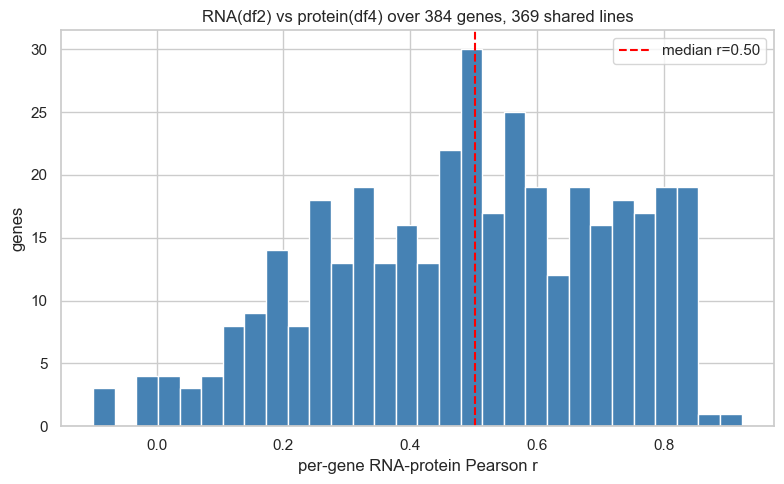

median r=0.503  %>0.3=78%  %<0=2%


In [18]:
import __init__ as ini, re
# protein columns here are 'UniProt (SYMBOL)' -> take the symbol
prot = df.copy()
prot.columns = [re.search(r"\(([^)]+)\)", c).group(1) if re.search(r"\(([^)]+)\)", c) else c
                for c in prot.columns]
prot = prot.loc[:, ~prot.columns.duplicated()]
psyms = set(prot.columns)
hdr = pd.read_csv(ini.df2, nrows=0).columns
sym2col = {}
for c in hdr[1:]:
    s = c.split(" (")[0]
    if s in psyms and s not in sym2col: sym2col[s] = c
pick = list(sym2col.values())[:400]
d2 = pd.read_csv(ini.df2, usecols=[hdr[0]] + pick).rename(columns={hdr[0]: "ProfileID"})
d8 = pd.read_csv(ini.df8, usecols=["ProfileID","ModelID","Datatype"])
p2m = d8[d8.Datatype=="rna"].drop_duplicates("ProfileID").set_index("ProfileID")["ModelID"].to_dict()
d2["model"] = d2.ProfileID.map(p2m)
d2 = d2.dropna(subset=["model"]).drop_duplicates("model").set_index("model").drop(columns="ProfileID")
d2.columns = [c.split(" (")[0] for c in d2.columns]
d2 = d2.loc[:, ~d2.columns.duplicated()]
shared = d2.index.intersection(prot.index)
rs = []
for g in [g for g in d2.columns if g in prot.columns]:
    a = d2.loc[shared, g].astype(float); b = prot.loc[shared, g].astype(float)
    ok = a.notna() & b.notna()
    if ok.sum() >= 30: rs.append(np.corrcoef(a[ok], b[ok])[0,1])
rs = pd.Series(rs)
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(rs, bins=30, color="steelblue", edgecolor="white")
ax.axvline(rs.median(), color="red", ls="--", label=f"median r={rs.median():.2f}")
ax.set_xlabel("per-gene RNA-protein Pearson r"); ax.set_ylabel("genes"); ax.legend()
ax.set_title(f"RNA(df2) vs protein(df4) over {len(rs)} genes, {len(shared)} shared lines")
plt.tight_layout(); plt.show()
print(f"median r={rs.median():.3f}  %>0.3={(rs>0.3).mean()*100:.0f}%  %<0={(rs<0).mean()*100:.0f}%")

## In Plain English — What This Dataset Means & Where It Goes Next

### 1. What this data actually is (layman terms)
Genes are the *instructions*; **proteins are the actual machines the cell builds from those instructions.** This file measures **how much of each protein is actually present** in each cell line (via mass spectrometry, i.e., a machine that weighs molecules to identify and count them). That makes it **closer to what the cell is really doing** than gene activity alone. The catch: it only covers **375 cell lines (~20% of the catalogue)**.

### 2. What we found, and the next steps (preprocessing + missing EDA)
What the notebook showed:
- **375 cell lines × 12,558 proteins**, keyed directly by `ModelID` (so it joins easily).
- Values are already **Z-scored** (i.e., re-centred so each protein's average is ~0 and differences are expressed in "standard steps").
- **Blank (NaN) means "this protein wasn't detected"** — a meaningful absence, not a random gap.
- A PCA explained less spread (16%) than RNA did (38%) — proteins are noisier / harder to measure.
- **RNA predicts protein only moderately (correlation ~0.46)** — which is exactly *why* protein is worth measuring separately.

Next steps (preprocessing):
- **Drop proteins that are >90% missing** (too sparse to be useful).
- **Handle remaining NaNs deliberately**: treat "not detected" as a low/floor value or add a "was-it-detected" flag, rather than silently averaging it away.
- **Document the heavy lineage bias** (lung-heavy coverage) so we don't over-trust it for under-covered tissues.

Still missing in EDA:
- A **decided imputation strategy** for the missing proteins, written down and justified.

### 3. Which ML approach fits this dataset
**Unsupervised feature source, used as enrichment only.** With just 375 lines it's too small to be a primary signal for supervised ranking, but where a cell line *does* have protein data it adds valuable "what the cell actually makes" evidence to justify a pick.

> **Big-picture note:** This is one of the optional enrichment layers on the DepMap spine — present for ~20% of lines, so the model must work with or without it.